# The Hidden Statistics Behind Credit Risk

Companion notebook for the RWDS _Foundations & Frontiers_ article.

**Paper**: Sudjianto & Burakov (2025), [arXiv:2509.09855](https://arxiv.org/abs/2509.09855)
**Dataset**: [Home Credit](https://huggingface.co/datasets/deburky/home-credit-credit-risk-model-stability) (522,596 loans, 10 features)

Three things a credit data scientist can do differently after reading this:

1. **Report a CI on IV** when ranking features — not just a point estimate.
2. **Test whether PSI movement is real drift** or sampling noise.
3. **Defend fairness constraints** under model risk review with probabilistic bounds.

All three flow from one fact: IV, PSI, and fairness IV are the same Jeffreys divergence, and the delta method gives standard errors.


## 1. Data


In [116]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
from fastwoe import FastWoe
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline

In [117]:
%config InlineBackend.figure_format = 'retina'

IMAGES = Path("../images")
IMAGES.mkdir(exist_ok=True)

# -------------------------------------------------------------------------------
# Color palette
# -------------------------------------------------------------------------------
C_DR = "#f187ff"
C_PD = "#53cef9"
C_DPD = "#7eff7e"
C_CB = "#7ebfff"
C_USER = "#ff7ebf"
C_CAT = "#c07fff"
C_FAIR = "#ed7d31"

# Set font to Arial
plt.rcParams["font.family"] = "Arial"

In [118]:
# -------------------------------------------------------------------------------
# Load processed dataset (local or HuggingFace)
# -------------------------------------------------------------------------------
HF = "hf://datasets/deburky/home-credit-credit-risk-model-stability/home_credit_processed.parquet"
LOCAL = Path("../data/processed/home_credit_processed.parquet")

# -------------------------------------------------------------------------------
# Feature definitions and human-readable names
# -------------------------------------------------------------------------------
rename_dict = {
    "target": "is_default",
    "education_927M": "education_level",
    "incometype_1044T": "income_type",
    "familystate_447L": "family_status",
    "language1_981M": "primary_language",
    "maritalst_385M": "marital_status",
    "requesttype_4525192L": "loan_request_type",
    "description_5085714M": "loan_description",
    "pctinstlsallpaidlat10d_839L": "pct_late_installments",
    "numberofqueries_373L": "num_credit_inquiries",
}

cols_to_use = ["target", "WEEK_NUM", "date_decision", "sex_738L"] + list(rename_dict.keys())

df = pd.read_parquet(LOCAL if LOCAL.exists() else HF, columns=list(set(cols_to_use)))
df = df.sort_values("date_decision").reset_index(drop=True)
df = df.rename(columns=rename_dict)

# -------------------------------------------------------------------------------
# Subsample: 10% stratified within each week (keeps all weeks, ~52K rows)
# -------------------------------------------------------------------------------
rng = np.random.default_rng(42)
sample_idx = (
    df.groupby("WEEK_NUM")
    .apply(lambda g: g.sample(frac=0.10, random_state=rng.integers(1e9)), include_groups=False)
    .index.get_level_values(1)
)
df = df.loc[sample_idx].reset_index(drop=True)

print(f"{df.shape[0]:,} rows, default rate {df['is_default'].mean():.2%}")
print(f"Weeks: {len(df['WEEK_NUM'].unique())} (all preserved)")

cat_features = [
    "education_level",
    "income_type",
    "family_status",
    "primary_language",
    "marital_status",
    "loan_request_type",
    "loan_description",
]
num_features = [
    "pct_late_installments",
    "num_credit_inquiries",
]
all_features = cat_features + num_features

X = df[all_features].copy()
y = df["is_default"]
sex_binary = (df["sex_738L"] == "M").astype(int)

X[cat_features] = X[cat_features].fillna("NA").astype(str)
X[num_features] = X[num_features].astype(float)

# Temporal split (80/20 by date)
split_idx = int(len(df) * 0.8)
ix_train = df.iloc[:split_idx].index
ix_test = df.iloc[split_idx:].index
print(f"Train: {len(ix_train):,}  Test: {len(ix_test):,}")

52,260 rows, default rate 3.27%
Weeks: 42 (all preserved)
Train: 41,808  Test: 10,452


## 2. IV = PSI = Jeffreys divergence

The paper proves that the industry IV formula is exactly the Jeffreys divergence (symmetric KL):

$$\text{IV} = \sum_{j}(p_{b,j} - p_{g,j})\,\ln\frac{p_{b,j}}{p_{g,j}} = D_\text{KL}(P_b \| P_g) + D_\text{KL}(P_g \| P_b)$$

The same formula on different partitions:

| Partition                       | Measures                              |
| ------------------------------- | ------------------------------------- |
| Good vs. Bad (target)           | **Predictive IV** — feature selection |
| Reference vs. Current (time)    | **PSI** — population drift            |
| Group 0 vs. Group 1 (protected) | **Fairness IV** — demographic bias    |

We use [FastWoe](https://github.com/xRiskLab/fastwoe) to compute IV with standard errors out of the box.


In [126]:
X_train = X.loc[ix_train].copy()
X_test = X.loc[ix_test].copy()
y_train = y.loc[ix_train].copy()
y_test = y.loc[ix_test].copy()

# -------------------------------------------------------------------------------
# Fit FastWoe encoder (tree-based binning)
# -------------------------------------------------------------------------------
woe_encoder = FastWoe(
    binning_method="tree",
    tree_kwargs={"max_depth": 3, "min_samples_leaf": 50},
)
woe_encoder.fit(X_train, y_train)

# -------------------------------------------------------------------------------
# Fit WOE Logistic Regression
# -------------------------------------------------------------------------------
pipeline = make_pipeline(woe_encoder, LogisticRegression(penalty=None, solver="newton-cg"))
pipeline.fit(X_train, y_train)

# IV analysis with standard errors, CIs, significance, and Gini
iv_analysis = woe_encoder.get_iv_analysis()
iv_analysis

,feature,iv,iv_se,iv_ci_lower,iv_ci_upper,iv_significance,n_categories,gini
7,pct_late_installments,0.2292,0.0181,0.1937,0.2646,Significant,8,0.2388
8,num_credit_inquiries,0.1587,0.0148,0.1297,0.1877,Significant,9,0.2039
5,loan_request_type,0.1196,0.0119,0.0962,0.1430,Significant,4,0.1672
1,income_type,0.1095,0.0118,0.0863,0.1327,Significant,8,0.1790
0,education_level,0.0483,0.0077,0.0331,0.0634,Significant,6,0.1069
6,loan_description,0.0445,0.0075,0.0297,0.0592,Significant,2,0.0773
3,primary_language,0.0245,0.0053,0.0141,0.0348,Significant,3,0.0769
4,marital_status,0.0229,0.0053,0.0125,0.0334,Significant,6,0.0792
2,family_status,0.0183,0.0047,0.0090,0.0276,Significant,6,0.0678


## 3. Standard errors, CIs, and hypothesis testing

WoE is log odds shifted by a constant (prior log odds). Because $\text{Var}(X - K) = \text{Var}(X)$, WoE inherits the SE of log odds unchanged:

$$\text{SE}(\text{WoE}_j) = \sqrt{\frac{1}{n_{j,g}} + \frac{1}{n_{j,b}}}$$

Since IV is a weighted sum of WoE, the delta method gives:

$$\text{SE}(\text{IV}) = \sqrt{\sum_j (p_{b,j}-p_{g,j})^2 \cdot \text{SE}(\text{WoE}_j)^2}$$

This enables:

- **95% CIs** on IV point estimates
- **Hypothesis test**: $H_0: \text{IV} = 0$ (no predictive power), $Z = \text{IV} / \text{SE}(\text{IV})$


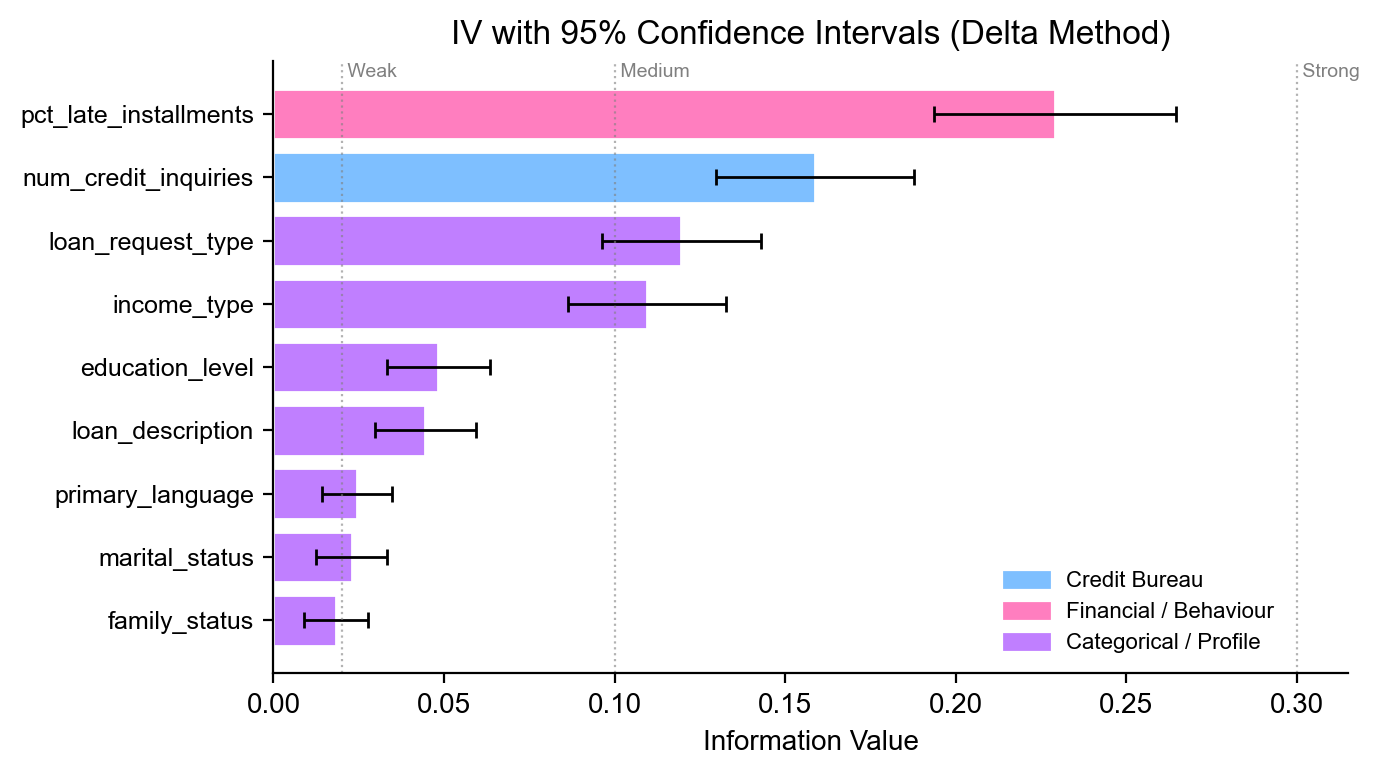

In [127]:
# -------------------------------------------------------------------------------
# Figure: IV with 95% confidence intervals, colored by feature group
# -------------------------------------------------------------------------------
iv_sorted = iv_analysis.sort_values("iv", ascending=True).reset_index(drop=True)

group_colors = {f: C_CAT for f in cat_features} | {
    f: C_USER for f in num_features if f != "num_credit_inquiries"
}
group_colors["num_credit_inquiries"] = C_CB

fig, ax = plt.subplots(figsize=(7, 4))
y_pos = np.arange(len(iv_sorted))
bar_colors = [group_colors.get(f, "#999") for f in iv_sorted["feature"]]
xerr = (iv_sorted["iv_ci_upper"] - iv_sorted["iv_ci_lower"]) / 2

ax.barh(
    y_pos,
    iv_sorted["iv"],
    xerr=xerr,
    height=0.8,
    color=bar_colors,
    edgecolor="white",
    capsize=3,
    error_kw={"linewidth": 1, "color": "#333"},
)
ax.set_yticks(y_pos)
ax.set_yticklabels(iv_sorted["feature"], fontsize=9)
ax.set_xlabel("Information Value")
ax.set_title("IV with 95% Confidence Intervals (Delta Method)")

for thr, lab in [(0.02, "Weak"), (0.1, "Medium"), (0.3, "Strong")]:
    ax.axvline(thr, color="grey", ls=":", lw=0.8, alpha=0.6)
    ax.text(thr, len(iv_sorted) - 0.2, f" {lab}", fontsize=7, color="grey", va="top")

legend_patches = [
    Patch(color=C_CB, label="Credit Bureau"),
    Patch(color=C_USER, label="Financial / Behaviour"),
    Patch(color=C_CAT, label="Categorical / Profile"),
]
ax.legend(
    handles=legend_patches, loc="lower right", bbox_to_anchor=(0.95, 0), frameon=False, fontsize=8
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(IMAGES / "iv_bar_chart.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Model performance and stability

FastWoe fits logistic regression on WoE-transformed features internally. We examine Gini, DR vs PD over time, and Gini stability by week.


In [128]:
# -------------------------------------------------------------------------------
# Gini (train / test)
# -------------------------------------------------------------------------------
def gini_score(y_true, y_pred) -> float:
    """Gini coefficient as a number between -1 and 1."""
    return 2 * roc_auc_score(y_true, y_pred) - 1


y_pred_train = pipeline.predict_proba(X_train)[:, 1]
y_pred_test = pipeline.predict_proba(X_test)[:, 1]

gini_train = gini_score(y_train, y_pred_train)
gini_test = gini_score(y_test, y_pred_test)
print(f"Train Gini: {gini_train:.2%}")
print(f"Test Gini:  {gini_test:.2%}")

Train Gini: 40.30%
Test Gini:  44.85%


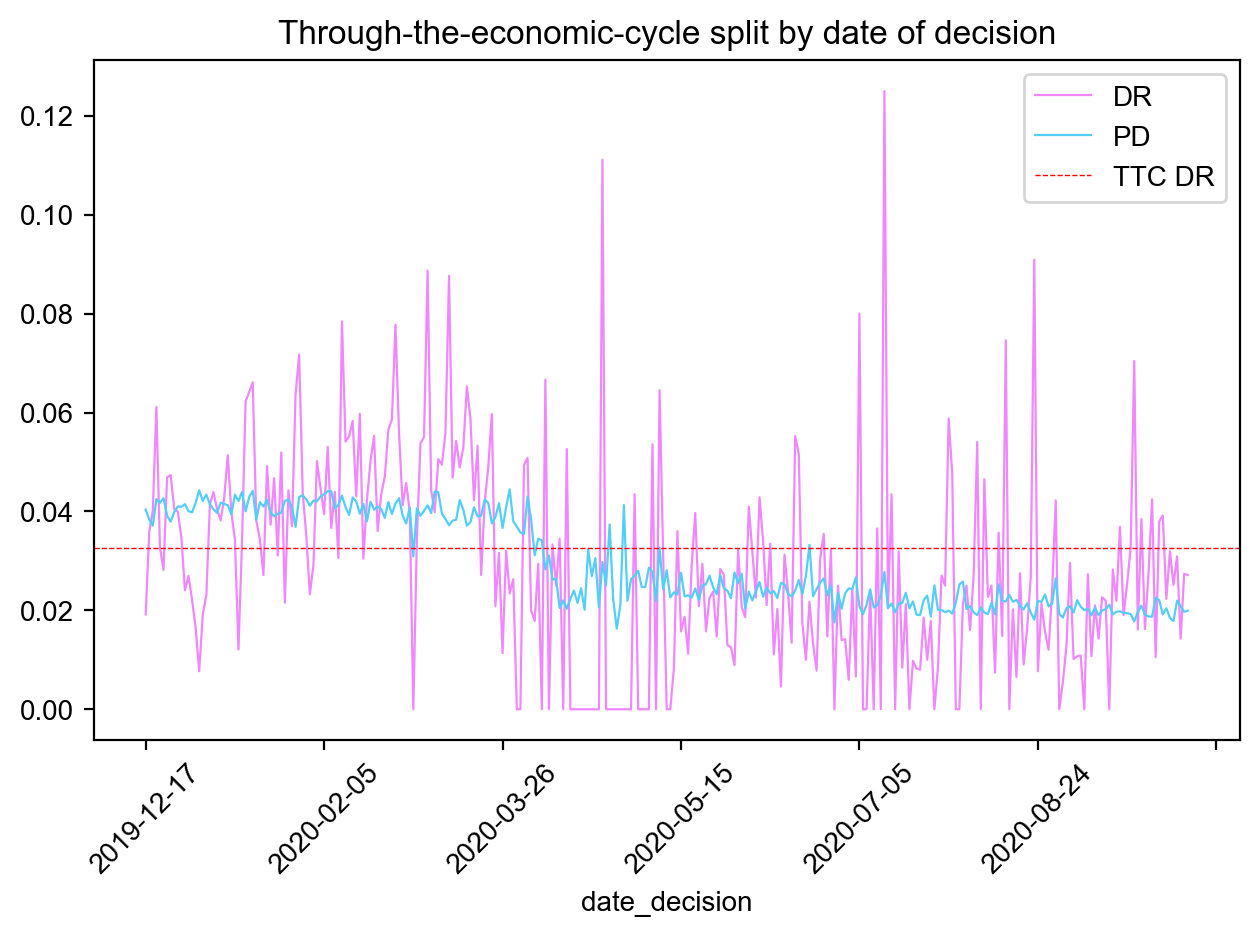

In [129]:
# -------------------------------------------------------------------------------
# Figure: DR vs PD over time
# -------------------------------------------------------------------------------
df["prediction"] = woe_encoder.predict_proba(X)[:, 1]
df["prediction"] = pipeline.predict_proba(X)[:, 1]

df["is_default"].groupby(df["date_decision"]).mean().plot(
    kind="line",
    color=C_DR,
    linewidth=0.8,
    label="DR",
    rot=45,
    title="Through-the-economic-cycle split by date of decision",
)
df["prediction"].groupby(df["date_decision"]).mean().plot(
    kind="line",
    color=C_PD,
    linewidth=0.8,
    label="PD",
    rot=45,
)
plt.axhline(y=df["is_default"].mean(), color="r", linestyle="--", linewidth=0.5, label="TTC DR")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGES / "dr_vs_pd_over_time.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. PSI drift inference

PSI is the same Jeffreys divergence computed across time windows. With standard errors, we can formally test whether observed drift is statistically significant or just sampling noise.

$$\text{PSI} = \sum_j (q_j - p_j)\ln\frac{q_j}{p_j}, \qquad \text{SE}(\text{PSI}) = \sqrt{\sum_j (q_j - p_j)^2 \left(\frac{1}{n^{\text{ref}}_j} + \frac{1}{n^{\text{comp}}_j}\right)}$$


In [130]:
# -------------------------------------------------------------------------------
# PSI over time for income_type — include all weeks
# -------------------------------------------------------------------------------
psi_feat = "pct_late_installments"
weeks = sorted(df["WEEK_NUM"].unique())
ref_weeks = weeks[:10]

series = df[psi_feat]
if series.dtype == object:

    def binner(s):
        """Bin WoE-encoded categorical features."""
        return s.fillna("NA").astype(str)
elif series.nunique() > 10:
    _, edges = pd.qcut(series.dropna(), q=10, duplicates="drop", retbins=True)
    edges[0], edges[-1] = -np.inf, np.inf

    def binner(s):
        """Bin numeric features."""
        return pd.cut(s.fillna(-999), bins=edges).astype(str)
else:

    def binner(s):
        """Bin numeric feature as string."""
        return s.fillna(-999).astype(str)


ref_counts = binner(df.loc[df["WEEK_NUM"].isin(ref_weeks), psi_feat]).value_counts()

psi_rows = []
# Include reference weeks as PSI=0
psi_rows.extend(
    {"week": w, "psi": 0.0, "se": 0.0, "z": 0.0, "significant": False} for w in ref_weeks
)
for w in weeks:
    if w in ref_weeks:
        continue
    ws = df.loc[df["WEEK_NUM"] == w, psi_feat]
    if len(ws) < 50:
        continue
    wc = binner(ws).value_counts()
    all_bins = sorted(set(ref_counts.index) | set(wc.index))
    r = np.array([ref_counts.get(b, 0) for b in all_bins], float)
    c = np.array([wc.get(b, 0) for b in all_bins], float)
    p = np.clip(r / r.sum(), 1e-15, None)
    q = np.clip(c / c.sum(), 1e-15, None)
    psi = float(((q - p) * np.log(q / p)).sum())
    se_ln = np.sqrt(1 / np.clip(r, 1, None) + 1 / np.clip(c, 1, None))
    se = float(np.sqrt(((q - p) ** 2 * se_ln**2).sum()))
    z = psi / se if se > 0 else 0
    psi_rows.append({"week": w, "psi": psi, "se": se, "z": z, "significant": z > 1.96})

psi_df = pd.DataFrame(psi_rows)
print(f"PSI for {psi_feat} (reference: weeks {ref_weeks})")
print(f"Weeks with significant drift: {psi_df['significant'].sum()} / {len(psi_df)}")
psi_df.head(10)

# -------------------------------------------------------------------------------
# Alternative PSI over time with dates
# -------------------------------------------------------------------------------
# Map each week number to its first date in that week
week_to_date = (
    df.groupby("WEEK_NUM")["date_decision"]
    .min()
    .reset_index()
    .rename(columns={"date_decision": "week_date"})
)
week_to_date["week_date"] = pd.to_datetime(week_to_date["week_date"])  # ensure datetime
psi_df = psi_df.merge(week_to_date, left_on="week", right_on="WEEK_NUM", how="left")

ref_dates = week_to_date.loc[week_to_date["WEEK_NUM"].isin(ref_weeks), "week_date"]

# Add secondary x-axis with dates
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())

# Use same tick positions as primary axis
week_ticks = ax.get_xticks()
week_ticks = [w for w in week_ticks if psi_df["week"].min() <= w <= psi_df["week"].max()]

# Map week numbers → dates
tick_dates = [
    week_to_date.set_index("WEEK_NUM")["week_date"].get(int(w), pd.NaT) for w in week_ticks
]
tick_labels = [d.strftime("%d %b %y") if pd.notna(d) else "" for d in tick_dates]

ax2.set_xticks(week_ticks)
ax2.set_xticklabels(tick_labels, fontsize=7, rotation=35, ha="left")
ax2.spines[["top", "right"]].set_visible(False)

ax.set(xlabel="Week", ylabel="PSI", title=f"PSI Drift Inference: {psi_feat}")

PSI for pct_late_installments (reference: weeks [50, 51, 52, 53, 54, 55, 56, 57, 58, 59])
Weeks with significant drift: 29 / 42


[Text(0.5, 46.0, 'Week'),
 Text(8.88888888888889, 0.5, 'PSI'),
 Text(0.5, 1.0, 'PSI Drift Inference: pct_late_installments')]

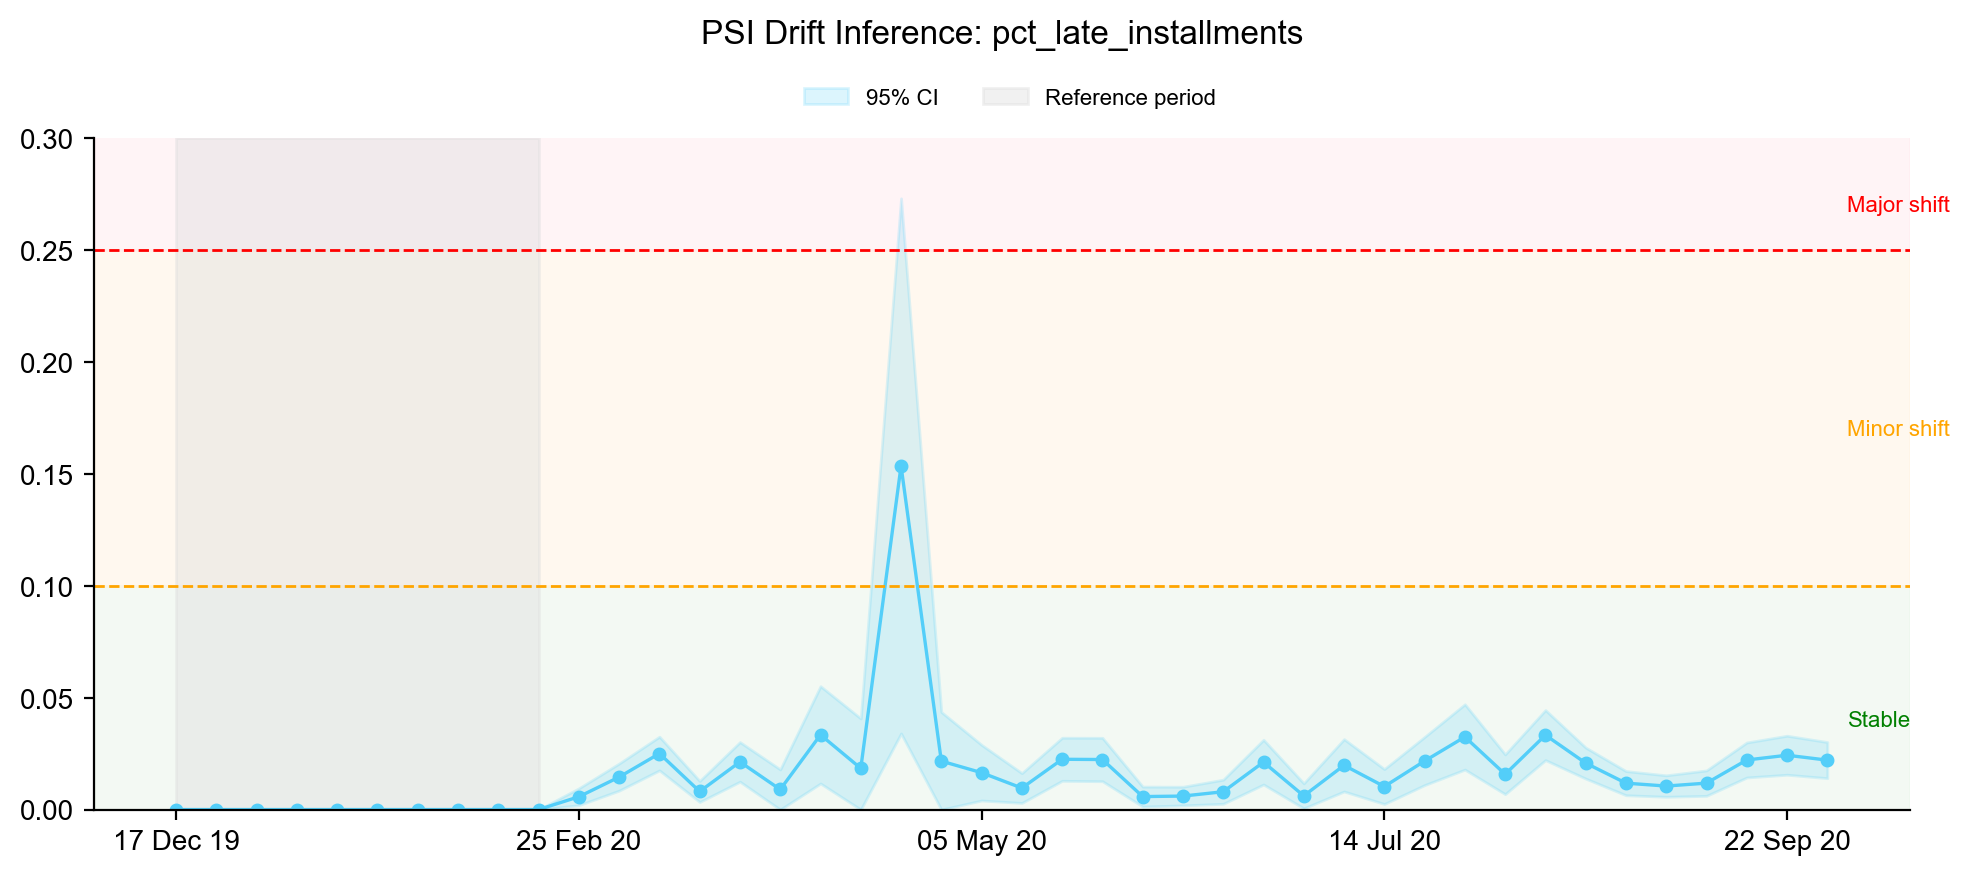

In [156]:
# -------------------------------------------------------------------------------
# Figure: PSI over time with CI bands and threshold zones
# -------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4.5))

alpha = 0.05
z = norm.ppf(1 - alpha / 2)

# Shade threshold zones
ax.axhspan(0, 0.1, color="#e8f5e9", alpha=0.5)
ax.axhspan(0.1, 0.25, color="#fff3e0", alpha=0.5)
ax.axhspan(0.25, 0.5, color="#ffebee", alpha=0.5)

ax.plot(psi_df["week"], psi_df["psi"], "o-", color=C_PD, ms=4, lw=1.2)
ax.fill_between(
    psi_df["week"],
    (psi_df["psi"] - z * psi_df["se"]).clip(lower=0),
    psi_df["psi"] + z * psi_df["se"],
    alpha=0.2,
    color=C_PD,
    label="95% CI",
)

ax.axhline(0.1, color="orange", ls="--", lw=1)
ax.axhline(0.25, color="red", ls="--", lw=1)

ax.text(psi_df["week"].max() + 0.5, 0.04, "Stable", fontsize=8, color="green", va="center")
ax.text(psi_df["week"].max() + 0.5, 0.17, "Minor shift", fontsize=8, color="orange", va="center")
ax.text(psi_df["week"].max() + 0.5, 0.27, "Major shift", fontsize=8, color="red", va="center")

ax.axvspan(ref_weeks[0], ref_weeks[-1], color="#ddd", alpha=0.4, label="Reference period")

ax.legend(bbox_to_anchor=(0.38, 1.105), loc="upper left", frameon=False, fontsize=8, ncol=2)

week_date_map = week_to_date.set_index("WEEK_NUM")["week_date"]

week_ticks = [w for w in ax.get_xticks() if psi_df["week"].min() <= w <= psi_df["week"].max()]

date_labels = []
for w in week_ticks:
    date = week_date_map.get(int(w), None)
    date_labels.append(date.strftime("%d %b %y") if date is not None else "")

ax.set_xticks(week_ticks)
ax.set_ylim(0, 0.3)
ax.set_xticklabels(date_labels, fontsize=10, rotation=0, ha="center")
ax.set_title(f"PSI Drift Inference: {psi_feat}", fontsize=12, pad=10, y=1.1)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(IMAGES / "psi_over_time.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Fairness as dual IV (extension)

The same Jeffreys divergence can measure demographic bias: compute IV of each feature against a protected attribute (e.g. sex) instead of the target. The paper (Section 6) formalises this as:

- **Maximise** $\text{IV}_\text{perf}$ (predictive power)
- **Minimise** $\text{IV}_\text{fair}$ (fairness)

With standard errors, hard thresholds become probabilistic: $P(\text{IV}_\text{fair} \leq \epsilon) \geq 95\%$.

We show the computation here; the full Pareto frontier and MIP optimisation are in the [paper](https://arxiv.org/abs/2509.09855).


In [39]:
# -------------------------------------------------------------------------------
# Predictive IV vs Demographic IV (vs. sex) for each feature
# -------------------------------------------------------------------------------
# Fit a separate FastWoe against sex to get demographic IV + SE
woe_fair = FastWoe(
    binning_method="tree",
    tree_kwargs={"max_depth": 3, "min_samples_leaf": 50},
)
woe_fair.fit(X_train, sex_binary.loc[ix_train])
fair_analysis = woe_fair.get_iv_analysis()

# Merge predictive and demographic IV
merged = iv_analysis[["feature", "iv", "iv_se"]].merge(
    fair_analysis[["feature", "iv", "iv_se"]],
    on="feature",
    suffixes=("_pred", "_demo"),
)

epsilon = 0.05
merged["p_fair"] = stats.norm.cdf(
    epsilon,
    loc=merged["iv_demo"],
    scale=merged["iv_se_demo"].clip(lower=1e-15),
)

flagged = merged[merged["p_fair"] < 0.95].sort_values("iv_demo", ascending=False)
print(f"Fairness threshold: IV_demo <= {epsilon} at 95% confidence")
print(f"Features flagged: {len(flagged)} / {len(merged)}\n")
if len(flagged):
    print(flagged[["feature", "iv_pred", "iv_demo", "iv_se_demo", "p_fair"]].to_string(index=False))
else:
    print("All features pass the fairness test.")

Fairness threshold: IV_demo <= 0.05 at 95% confidence
Features flagged: 5 / 9

              feature  iv_pred  iv_demo  iv_se_demo        p_fair
          income_type   0.1095   0.3450      0.0083 5.488996e-277
       marital_status   0.0229   0.1762      0.0079  9.591272e-58
    loan_request_type   0.1196   0.0793      0.0038  6.264996e-15
        family_status   0.0183   0.0780      0.0043  3.717034e-11
pct_late_installments   0.2292   0.0465      0.0029  8.862640e-01


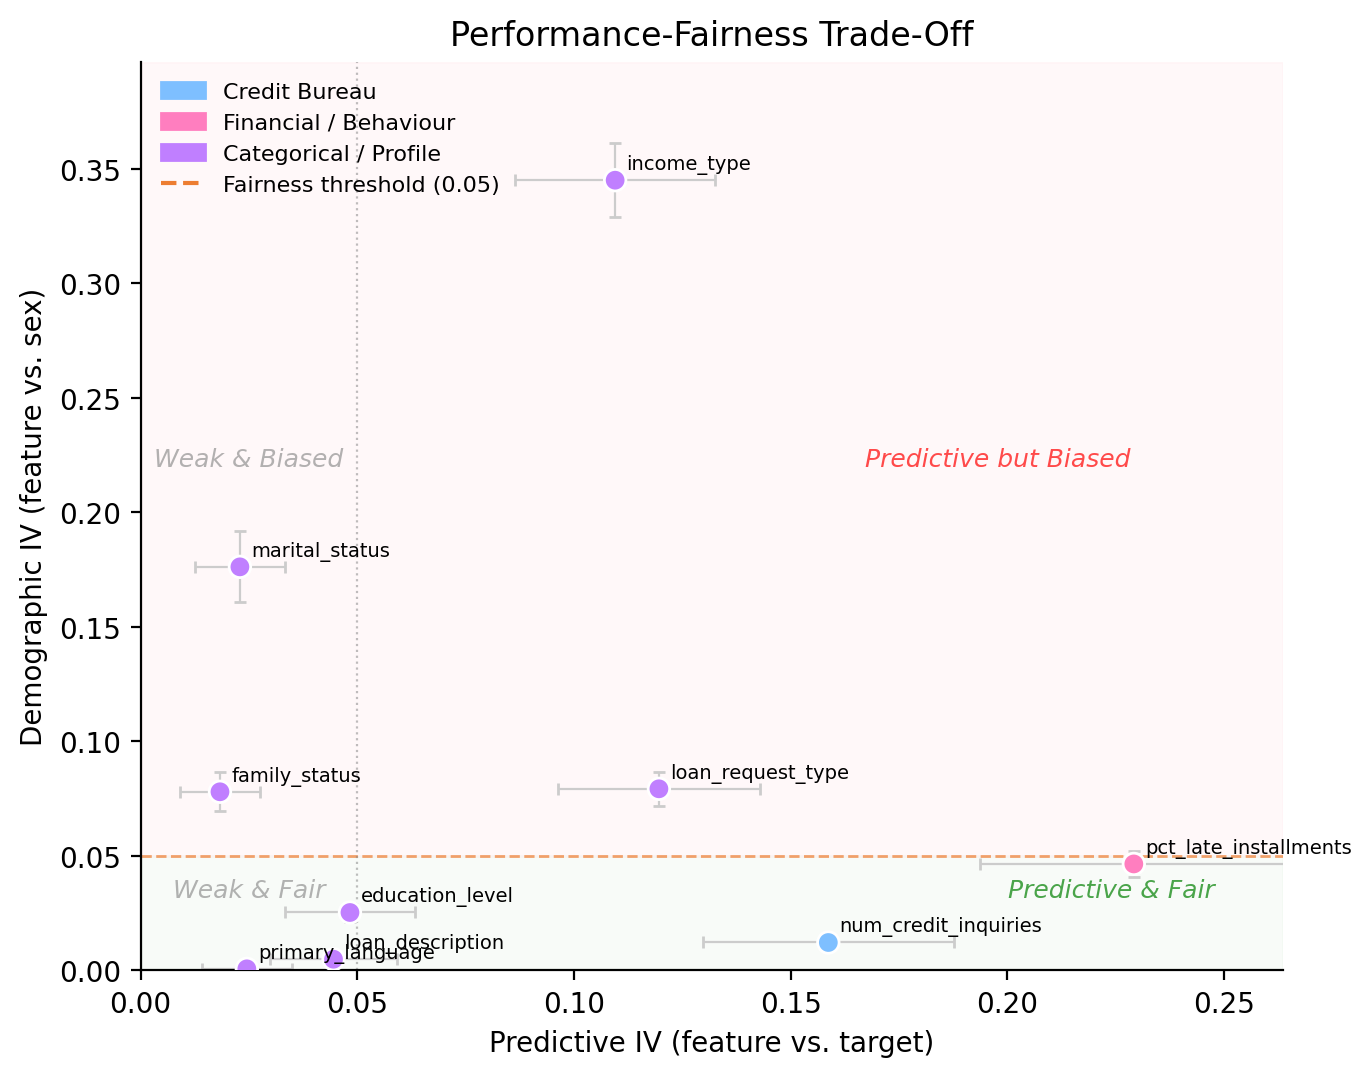

In [52]:
# -------------------------------------------------------------------------------
# Figure: Predictive IV vs Demographic IV with quadrant labels
# -------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5.5))

# Shade quadrants
iv_mid = 0.05  # fairness threshold (y-axis)
pred_mid = 0.05  # predictive relevance threshold (x-axis)
xlim = max(merged["iv_pred"].max() * 1.15, 0.25)
ylim = max(merged["iv_demo"].max() * 1.15, 0.10)

# Bottom-right: high IV, low bias — ideal
ax.axhspan(0, iv_mid, xmin=0, xmax=1, color="#e8f5e9", alpha=0.3)
# Top: high bias zone
ax.axhspan(iv_mid, ylim, color="#ffebee", alpha=0.3)

# Quadrant labels
ax.text(
    xlim * 0.85,
    iv_mid * 0.7,
    "Predictive & Fair",
    fontsize=9,
    ha="center",
    va="center",
    color="green",
    alpha=0.7,
    style="italic",
)
ax.text(
    xlim * 0.75,
    iv_mid + (ylim - iv_mid) * 0.5,
    "Predictive but Biased",
    fontsize=9,
    ha="center",
    va="center",
    color="red",
    alpha=0.7,
    style="italic",
)
ax.text(
    pred_mid * 0.5,
    iv_mid * 0.7,
    "Weak & Fair",
    fontsize=9,
    ha="center",
    va="center",
    color="grey",
    alpha=0.6,
    style="italic",
)
ax.text(
    pred_mid * 0.5,
    iv_mid + (ylim - iv_mid) * 0.5,
    "Weak & Biased",
    fontsize=9,
    ha="center",
    va="center",
    color="grey",
    alpha=0.6,
    style="italic",
)

# Scatter
scatter_colors = [group_colors.get(f, "#999") for f in merged["feature"]]
ax.scatter(
    merged["iv_pred"], merged["iv_demo"], c=scatter_colors, s=60, edgecolors="white", zorder=3
)
ax.errorbar(
    merged["iv_pred"],
    merged["iv_demo"],
    xerr=1.96 * merged["iv_se_pred"],
    yerr=1.96 * merged["iv_se_demo"],
    fmt="none",
    ecolor="#ccc",
    elinewidth=0.8,
    capsize=2,
    zorder=2,
)

for _, r in merged.iterrows():
    ax.annotate(
        r["feature"],
        (r["iv_pred"], r["iv_demo"]),
        fontsize=7,
        xytext=(4, 4),
        textcoords="offset points",
    )

# Threshold lines
ax.axhline(iv_mid, color=C_FAIR, ls="--", lw=1, alpha=0.7)
ax.axvline(pred_mid, color="grey", ls=":", lw=0.8, alpha=0.5)

legend_patches = [
    Patch(color=C_CB, label="Credit Bureau"),
    Patch(color=C_USER, label="Financial / Behaviour"),
    Patch(color=C_CAT, label="Categorical / Profile"),
    plt.Line2D([0], [0], color=C_FAIR, ls="--", label=f"Fairness threshold ({iv_mid})"),
]
ax.legend(handles=legend_patches, loc="upper left", frameon=False, fontsize=8)

ax.set(
    xlabel="Predictive IV (feature vs. target)",
    ylabel="Demographic IV (feature vs. sex)",
    title="Performance-Fairness Trade-Off",
    xlim=(0, xlim),
    ylim=(0, ylim),
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(IMAGES / "pareto_predictive_vs_demographic.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
pd.crosstab(
    [
        df["income_type"].astype(str),
    ],
    df["sex_738L"],
    normalize=True,
)

sex_738L,F,M
income_type,,
EMPLOYED,0.093877,0.098316
HANDICAPPED_2,0.002315,0.001875
HANDICAPPED_3,0.001320,0.001493
OTHER,0.001072,0.006889
PRIVATE_SECTOR_EMPLOYEE,0.131362,0.134233
RETIRED_PENSIONER,0.185170,0.056525
SALARIED_GOVT,0.194910,0.070264
SELFEMPLOYED,0.013203,0.007176


### IV density by demographic group

A more nuanced fairness test: compute IV _separately_ for each sex group on shared bins, then test whether the _difference_ in IV is significant. The delta method gives SE for each group's IV; the SE of the difference is $\sqrt{\text{SE}_0^2 + \text{SE}_1^2}$.


In [59]:
# -------------------------------------------------------------------------------
# IV by demographic group for a borderline feature
# -------------------------------------------------------------------------------
test_feat = "pct_late_installments"
sex_col = df["sex_738L"]

# Shared bins from the full training data
feat_series = X_train[test_feat].astype(float)
n_bins = 5
if feat_series.nunique() > n_bins:
    shared_bins = pd.qcut(feat_series.dropna(), q=n_bins, duplicates="drop").cat.categories
else:
    shared_bins = None


def iv_se_with_bins(x, y, bins):
    """IV and SE using shared bins."""
    binned = pd.cut(x, bins=bins, include_lowest=True)
    tmp = pd.DataFrame({"bin": binned, "y": y})
    agg = tmp.groupby("bin", observed=False)["y"].agg(["count", "sum"]).reset_index()
    agg["good"], agg["bad"] = agg["sum"], agg["count"] - agg["sum"]
    total_good, total_bad = agg["good"].sum(), agg["bad"].sum()
    if total_good == 0 or total_bad == 0:
        return 0.0, 0.0
    pg = np.clip(agg["good"] / total_good, 1e-15, None)
    pb = np.clip(agg["bad"] / total_bad, 1e-15, None)
    woe = np.log(pg / pb)
    w = pg - pb
    iv = float((w * woe).sum())
    var_woe = 1 / np.clip(agg["good"], 1, None) + 1 / np.clip(agg["bad"], 1, None)
    se = float(np.sqrt((w**2 * var_woe).sum()))
    return iv, se


# Compute IV for each sex group
mask_f = sex_col.loc[ix_train] == "F"
mask_m = sex_col.loc[ix_train] == "M"

iv_f, se_f = iv_se_with_bins(
    X_train.loc[mask_f, test_feat].astype(float), y_train.loc[mask_f], shared_bins
)
iv_m, se_m = iv_se_with_bins(
    X_train.loc[mask_m, test_feat].astype(float), y_train.loc[mask_m], shared_bins
)

iv_diff = iv_m - iv_f
se_diff = np.sqrt(se_f**2 + se_m**2)
z_diff = iv_diff / se_diff if se_diff > 0 else 0
p_diff = 2 * (1 - stats.norm.cdf(abs(z_diff)))

n_f, n_m = mask_f.sum(), mask_m.sum()
print(f"Feature: {test_feat}")
print(f"Female (n={n_f:,}): IV = {iv_f:.4f} +/- {se_f:.4f}")
print(f"Male (n={n_m:,}): IV = {iv_m:.4f} +/- {se_m:.4f}")
print(f"Difference: dIV = {iv_diff:.4f} +/- {se_diff:.4f}")
print(
    f"Z = {z_diff:.2f}, p = {p_diff:.4f} {'(significant)' if p_diff < 0.05 else '(not significant)'}"
)

Feature: pct_late_installments
Female (n=25,780): IV = 0.3057 +/- 0.0216
Male (n=16,028): IV = 0.2147 +/- 0.0204
Difference: dIV = -0.0910 +/- 0.0297
Z = -3.07, p = 0.0022 (significant)


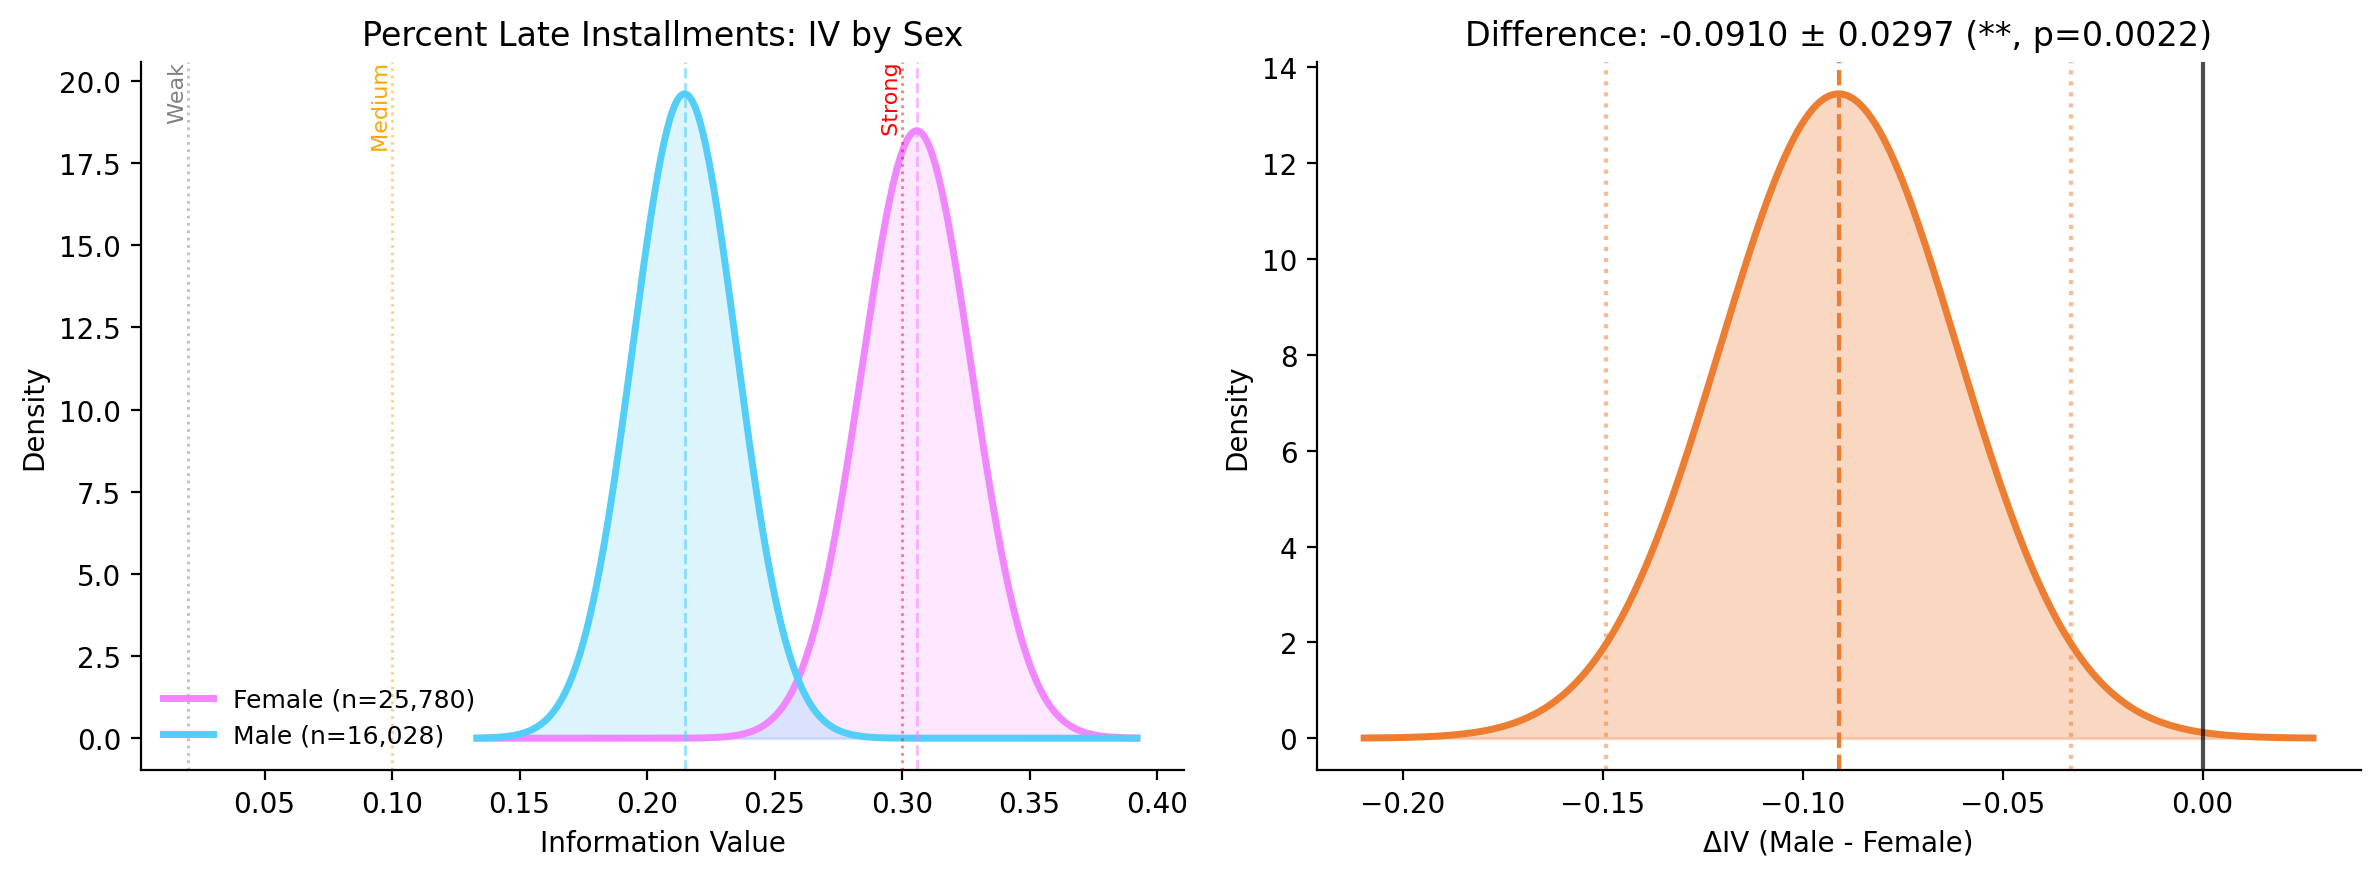

In [70]:
# -------------------------------------------------------------------------------
# Figure: IV density by group + difference distribution
# -------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: IV distributions for each group
iv_min = min(iv_f - 4 * se_f, iv_m - 4 * se_m)
iv_max = max(iv_f + 4 * se_f, iv_m + 4 * se_m)
x = np.linspace(max(0, iv_min), iv_max, 500)

pdf_f = stats.norm.pdf(x, iv_f, se_f)
pdf_m = stats.norm.pdf(x, iv_m, se_m)

ax1.plot(x, pdf_f, color=C_DR, lw=2.5, label=f"Female (n={n_f:,})")
ax1.fill_between(x, pdf_f, alpha=0.2, color=C_DR)
ax1.plot(x, pdf_m, color=C_PD, lw=2.5, label=f"Male (n={n_m:,})")
ax1.fill_between(x, pdf_m, alpha=0.2, color=C_PD)

ax1.axvline(iv_f, color=C_DR, ls="--", lw=1, alpha=0.6)
ax1.axvline(iv_m, color=C_PD, ls="--", lw=1, alpha=0.6)

for thr, lab, c in [(0.02, "Weak", "grey"), (0.1, "Medium", "orange"), (0.3, "Strong", "red")]:
    if thr <= iv_max:
        ax1.axvline(thr, color=c, ls=":", alpha=0.5, lw=1)
        ax1.text(
            thr,
            max(pdf_f.max(), pdf_m.max()) * 1.05,
            f" {lab}",
            rotation=90,
            va="top",
            ha="right",
            color=c,
            fontsize=8,
        )

test_feat_name = "Percent Late Installments"
ax1.set(xlabel="Information Value", ylabel="Density", title=f"{test_feat_name}: IV by Sex")
ax1.legend(frameon=False, fontsize=9, loc="lower left")
ax1.spines[["top", "right"]].set_visible(False)

# Right: difference distribution
x_diff = np.linspace(iv_diff - 4 * se_diff, iv_diff + 4 * se_diff, 500)
pdf_diff = stats.norm.pdf(x_diff, iv_diff, se_diff)

ax2.plot(x_diff, pdf_diff, color=C_FAIR, lw=2.5)
ax2.fill_between(x_diff, pdf_diff, alpha=0.3, color=C_FAIR)
ax2.axvline(0, color="black", lw=1.5, alpha=0.7)
ax2.axvline(iv_diff, color=C_FAIR, ls="--", lw=1.5)

ci_lo = iv_diff - 1.96 * se_diff
ci_hi = iv_diff + 1.96 * se_diff
ax2.axvline(ci_lo, color=C_FAIR, ls=":", alpha=0.5)
ax2.axvline(ci_hi, color=C_FAIR, ls=":", alpha=0.5)

sig = "***" if p_diff < 0.001 else "**" if p_diff < 0.01 else "*" if p_diff < 0.05 else "ns"
ax2.set(
    xlabel="ΔIV (Male - Female)",
    ylabel="Density",
    title=f"Difference: {iv_diff:.4f} ± {se_diff:.4f} ({sig}, p={p_diff:.4f})",
)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(IMAGES / "iv_density_by_group.png", dpi=200, bbox_inches="tight")
plt.show()

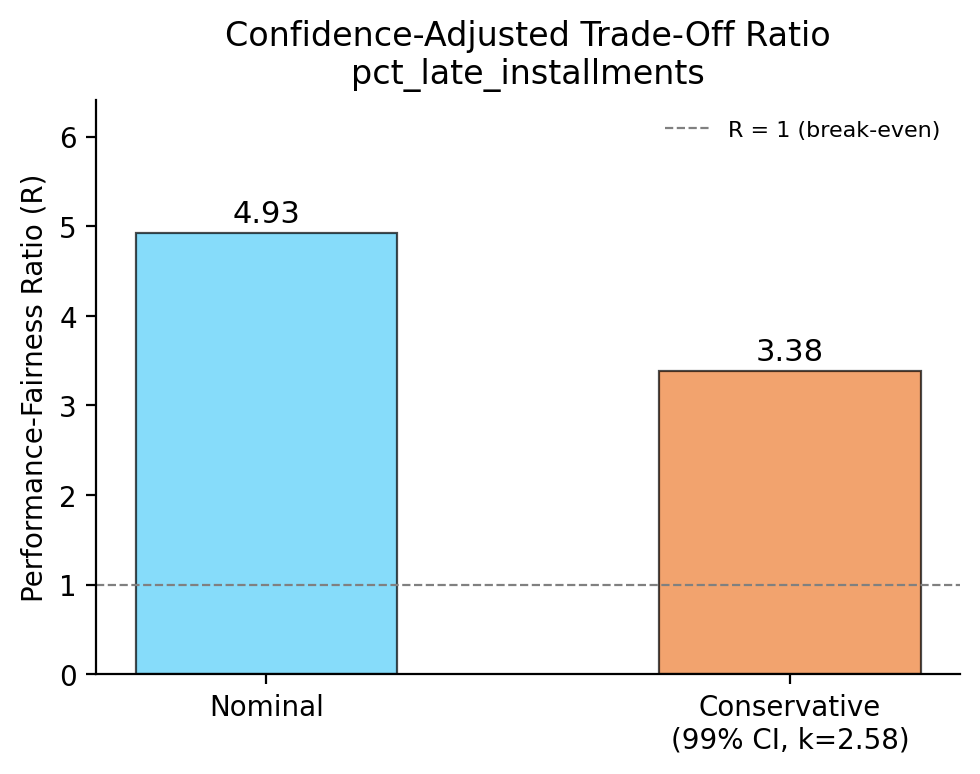


pct_late_installments:
IV_perf = 0.2292 +/- 0.0181
IV_fair = 0.0465 +/- 0.0029
R_nominal = 4.93
R_conservative = 3.38 (at 99% CI)


In [61]:
# -------------------------------------------------------------------------------
# Figure: Nominal vs Conservative performance-fairness ratio
# R = IV_perf / IV_fair  vs  R_conservative = (IV_perf - k*SE) / (IV_fair + k*SE)
# -------------------------------------------------------------------------------
row = merged[merged["feature"] == test_feat].iloc[0]
iv_perf, se_perf = row["iv_pred"], row["iv_se_pred"]
iv_fair, se_fair = row["iv_demo"], row["iv_se_demo"]

alpha = 0.01
k = stats.norm.ppf(1 - alpha / 2)

r_nominal = iv_perf / iv_fair
r_conservative = (iv_perf - k * se_perf) / (iv_fair + k * se_fair)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    ["Nominal", f"Conservative\n({100 * (1 - alpha):.0f}% CI, k={k:.2f})"],
    [r_nominal, r_conservative],
    color=[C_PD, C_FAIR],
    alpha=0.7,
    edgecolor="black",
    linewidth=0.8,
    width=0.5,
)
ax.axhline(y=1, color="grey", linestyle="--", linewidth=0.8, label="R = 1 (break-even)")
ax.set_ylabel("Performance-Fairness Ratio (R)")
ax.set_title(f"Confidence-Adjusted Trade-Off Ratio\n{test_feat}")
ax.set_ylim(0, max(r_nominal, r_conservative) * 1.3)

for bar, val in zip(bars, [r_nominal, r_conservative]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.05,
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=11,
    )

ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(IMAGES / "conservative_ratio.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\n{test_feat}:")
print(f"IV_perf = {iv_perf:.4f} +/- {se_perf:.4f}")
print(f"IV_fair = {iv_fair:.4f} +/- {se_fair:.4f}")
print(f"R_nominal = {r_nominal:.2f}")
print(f"R_conservative = {r_conservative:.2f} (at {100 * (1 - alpha):.0f}% CI)")